# Exploratory Data Analysis & Statistical Signifance Testing
In this notebook, we analyze trader performance and microstructure metrics across Bitcoin sentiment regimes. We back all claims with statistical tests (ANOVA/Kruskal-Wallis, Mann-Whitney U, and Permutation tests) and calculate bootstrap confidence intervals.

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../')
from src.feature_engineering import bootstrap_ci

ROOT = Path.cwd().parent
CSV = ROOT / 'csv_files'
OUT = ROOT / 'outputs'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
SEED = 42
rng = np.random.default_rng(SEED)

## Load Merged Clean Dataset

In [2]:
df = pd.read_csv(CSV / 'historical_with_sentiment_clean.csv')
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
print(f"Loaded {len(df)} rows.")

Loaded 211082 rows.


## Distribution Diagnostics & Tail Analysis
We inspect data distributions and plot Q-Q diagnostic charts to understand skewness and winsorization impact.

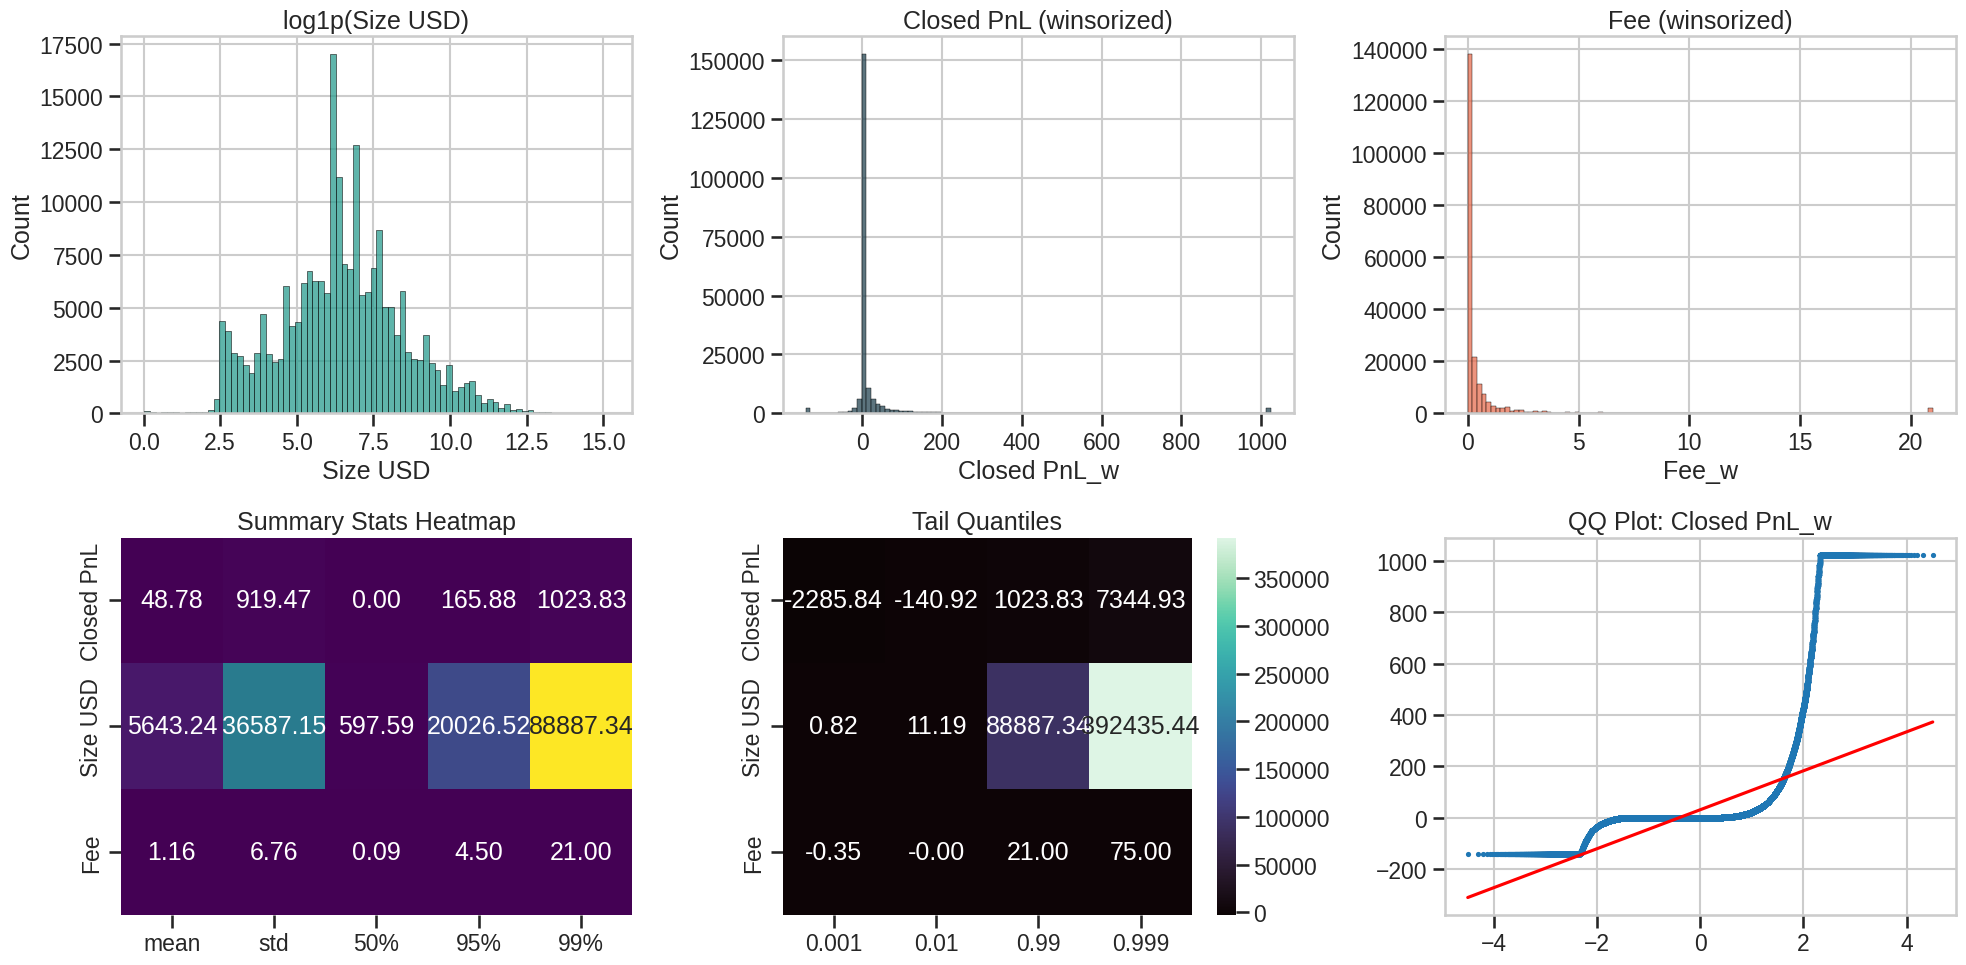

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.histplot(np.log1p(df['Size USD'].clip(lower=0)), bins=80, ax=axes[0,0], color='#2a9d8f')
axes[0,0].set_title('log1p(Size USD)')

sns.histplot(df['Closed PnL_w'], bins=100, ax=axes[0,1], color='#264653')
axes[0,1].set_title('Closed PnL (winsorized)')

sns.histplot(df['Fee_w'], bins=100, ax=axes[0,2], color='#e76f51')
axes[0,2].set_title('Fee (winsorized)')

stats_df = df[['Closed PnL','Size USD','Fee']].describe(percentiles=[.01,.05,.5,.95,.99]).T
sns.heatmap(stats_df[['mean','std','50%','95%','99%']], annot=True, fmt='.2f', cmap='viridis', ax=axes[1,0], cbar=False)
axes[1,0].set_title('Summary Stats Heatmap')

tail = df[['Closed PnL','Size USD','Fee']].quantile([0.001, 0.01, 0.99, 0.999]).T
sns.heatmap(tail, annot=True, fmt='.2f', cmap='mako', ax=axes[1,1])
axes[1,1].set_title('Tail Quantiles')

qq = stats.probplot(df['Closed PnL_w'], dist='norm')
axes[1,2].scatter(qq[0][0], qq[0][1], s=5)
axes[1,2].plot(qq[0][0], qq[1][1] + qq[1][0]*qq[0][0], color='red')
axes[1,2].set_title('QQ Plot: Closed PnL_w')

plt.tight_layout()
plt.savefig(OUT / 'figures/quant_distribution_diagnostics.png', dpi=180, bbox_inches='tight')
plt.show()

## Regime Performance & Bootstrap Confidence Intervals
We analyze trader performance metrics across the sentiment regimes with 95% bootstrap confidence intervals for average trade PnL.

In [4]:
regime_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
df['fg_classification'] = pd.Categorical(df['fg_classification'], categories=regime_order, ordered=True)

rows = []
for r, g in df.groupby('fg_classification'):
    avg, lo, hi = bootstrap_ci(g['Closed PnL_w'].values, n_boot=500, seed=SEED)
    rows.append({
        'regime': r,
        'trades': len(g),
        'accounts': g['Account'].nunique(),
        'volume_usd': g['Size USD'].sum(),
        'avg_pnl_w': avg,
        'avg_pnl_ci_lo': lo,
        'avg_pnl_ci_hi': hi,
        'median_pnl': g['Closed PnL'].median(),
        'win_rate': (g['Closed PnL'] > 0).mean(),
        'maker_rate': (g['Crossed'] == False).mean(),
        'taker_rate': (g['Crossed'] == True).mean(),
        'avg_fee': g['Fee'].mean(),
    })

reg_summary = pd.DataFrame(rows)
reg_summary.to_csv(CSV / 'advanced_regime_metrics.csv', index=False)
reg_summary.to_csv(ROOT / 'data' / 'advanced_regime_metrics.csv', index=False)
reg_summary

,regime,trades,accounts,volume_usd,avg_pnl_w,avg_pnl_ci_lo,avg_pnl_ci_hi,median_pnl,win_rate,maker_rate,taker_rate,avg_fee
0,Extreme Fear,21300,32,1.164264e+08,37.709026,35.508042,39.688259,0.0,0.417934,0.405352,0.594648,1.208836
1,Fear,61468,32,4.863485e+08,28.554146,27.561221,29.556315,0.0,0.420951,0.401933,0.598067,1.482190
2,Neutral,39553,31,1.917417e+08,23.595842,22.431623,24.743626,0.0,0.362602,0.405127,0.594873,1.063290
3,Greed,48613,31,2.695059e+08,32.492979,31.219215,33.724377,0.0,0.393640,0.378273,0.621727,1.219976
4,Extreme Greed,40148,30,1.271648e+08,38.411354,37.114604,39.882115,0.0,0.463635,0.375311,0.624689,0.688434


## Plot Performance by Sentiment Regime

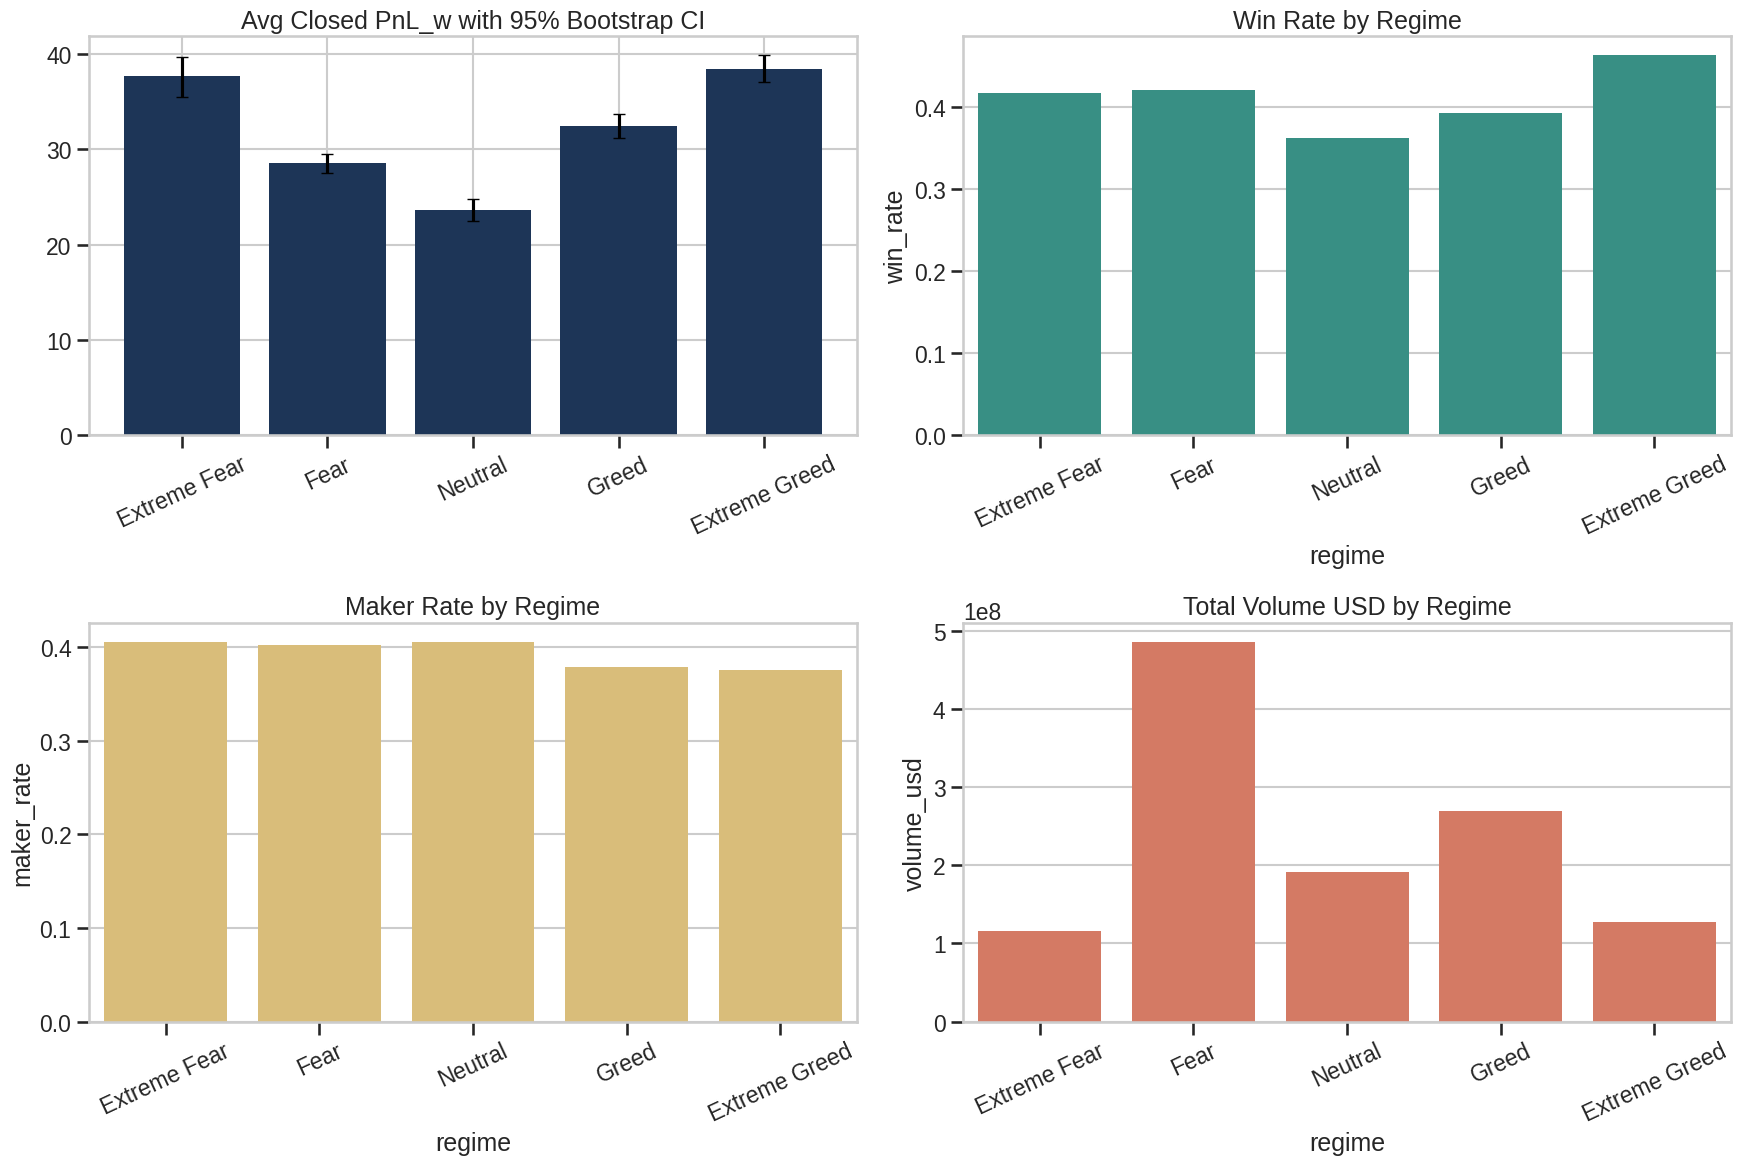

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0,0].bar(reg_summary['regime'].astype(str), reg_summary['avg_pnl_w'], color='#1d3557')
axes[0,0].errorbar(reg_summary['regime'].astype(str), reg_summary['avg_pnl_w'],
                   yerr=[reg_summary['avg_pnl_w'] - reg_summary['avg_pnl_ci_lo'], reg_summary['avg_pnl_ci_hi'] - reg_summary['avg_pnl_w']],
                   fmt='none', ecolor='black', capsize=4)
axes[0,0].set_title('Avg Closed PnL_w with 95% Bootstrap CI')
axes[0,0].tick_params(axis='x', rotation=25)

sns.barplot(data=reg_summary, x='regime', y='win_rate', ax=axes[0,1], color='#2a9d8f')
axes[0,1].set_title('Win Rate by Regime')
axes[0,1].tick_params(axis='x', rotation=25)

sns.barplot(data=reg_summary, x='regime', y='maker_rate', ax=axes[1,0], color='#e9c46a')
axes[1,0].set_title('Maker Rate by Regime')
axes[1,0].tick_params(axis='x', rotation=25)

sns.barplot(data=reg_summary, x='regime', y='volume_usd', ax=axes[1,1], color='#e76f51')
axes[1,1].set_title('Total Volume USD by Regime')
axes[1,1].tick_params(axis='x', rotation=25)
axes[1,1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.tight_layout()
plt.savefig(OUT / 'figures/quant_regime_core_metrics.png', dpi=180, bbox_inches='tight')
plt.show()

## Statistical Significance Tests & Permutation Tests
We use Kruskal-Wallis to check variance across all regimes, and Mann-Whitney U for pairwise checks.

In [6]:
groups = [df.loc[df['fg_classification'] == r, 'Closed PnL_w'].dropna().values for r in regime_order if (df['fg_classification'] == r).any()]
kw = stats.kruskal(*groups)

# Effect size eta^2
vals = df[['fg_classification', 'Closed PnL_w']].dropna()
mu = vals['Closed PnL_w'].mean()
ss_between = vals.groupby('fg_classification')['Closed PnL_w'].count().mul((vals.groupby('fg_classification')['Closed PnL_w'].mean() - mu)**2).sum()
ss_total = ((vals['Closed PnL_w'] - mu)**2).sum()
eta2 = ss_between / ss_total if ss_total > 0 else 0.0

test_rows = [{'test': 'kruskal_all_regimes', 'group_a': 'ALL', 'group_b': 'ALL', 'statistic': float(kw.statistic), 'p_value': float(kw.pvalue), 'effect_size': float(eta2)}]

# Pairwise Mann-Whitney U
for i, a in enumerate(regime_order):
    xa = df.loc[df['fg_classification'] == a, 'Closed PnL_w'].dropna().values
    if len(xa) == 0: continue
    for b in regime_order[i+1:]:
        xb = df.loc[df['fg_classification'] == b, 'Closed PnL_w'].dropna().values
        if len(xb) == 0: continue
        xa_s = rng.choice(xa, size=min(len(xa), 10000), replace=False)
        xb_s = rng.choice(xb, size=min(len(xb), 10000), replace=False)
        u, p = stats.mannwhitneyu(xa_s, xb_s, alternative='two-sided')
        rb = 1 - (2 * u) / (len(xa_s) * len(xb_s))
        test_rows.append({
            'test': 'mann_whitney_pairwise', 'group_a': a, 'group_b': b,
            'statistic': float(u), 'p_value': float(p), 'effect_size': float(rb)
        })

tests_df = pd.DataFrame(test_rows)
tests_df.to_csv(CSV / 'statistical_tests_regime.csv', index=False)
tests_df.to_csv(ROOT / 'data' / 'statistical_tests_regime.csv', index=False)
tests_df

,test,group_a,group_b,statistic,p_value,effect_size
0,kruskal_all_regimes,ALL,ALL,1.219249e+03,1.069365e-262,0.001506
1,mann_whitney_pairwise,Extreme Fear,Fear,4.967487e+07,3.961121e-01,0.006503
2,mann_whitney_pairwise,Extreme Fear,Neutral,5.291693e+07,1.724063e-14,-0.058339
3,mann_whitney_pairwise,Extreme Fear,Greed,5.151067e+07,8.629293e-05,-0.030213
4,mann_whitney_pairwise,Extreme Fear,Extreme Greed,4.747429e+07,6.569348e-11,0.050514
5,mann_whitney_pairwise,Fear,Neutral,5.267822e+07,1.054584e-12,-0.053564
6,mann_whitney_pairwise,Fear,Greed,5.195802e+07,2.767217e-07,-0.039160
7,mann_whitney_pairwise,Fear,Extreme Greed,4.730509e+07,1.678425e-12,0.053898
8,mann_whitney_pairwise,Neutral,Greed,4.791708e+07,3.528360e-08,0.041658
9,mann_whitney_pairwise,Neutral,Extreme Greed,4.314477e+07,9.748299e-73,0.137105


## Daily Sentiment Transition Matrix
We compute and plot the probability of transitioning between Fear/Greed states daily.

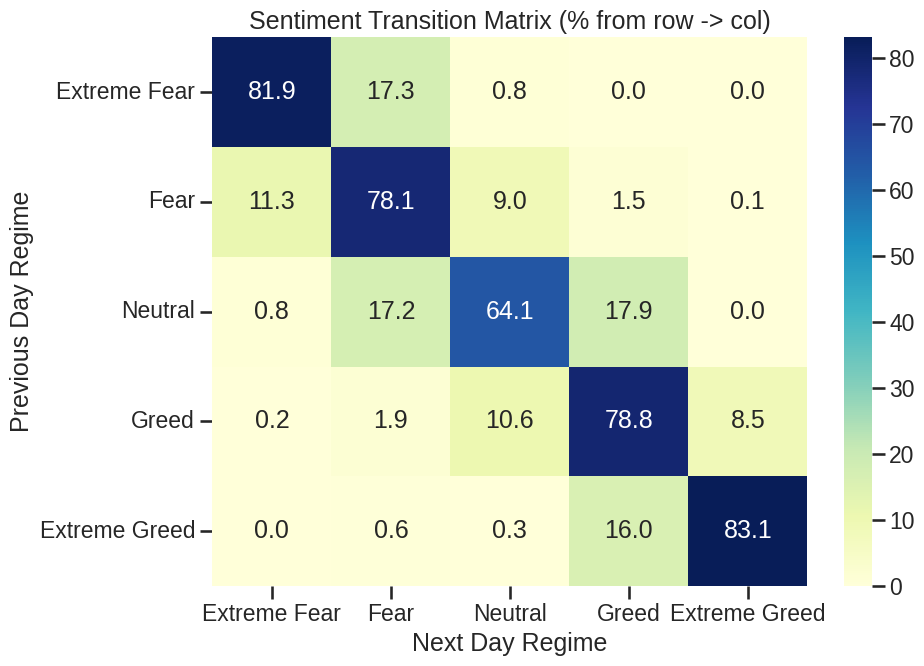

In [7]:
fg = pd.read_csv(ROOT / 'data' / 'fear_greed_index.csv')
fg['date'] = pd.to_datetime(fg['date'])
fg = fg.sort_values('date').copy()
fg['prev_class'] = fg['classification'].shift(1)
trans = pd.crosstab(fg['prev_class'], fg['classification'], normalize='index') * 100
trans = trans.reindex(index=regime_order, columns=regime_order).fillna(0)

trans.to_csv(CSV / 'advanced_regime_transition_matrix.csv')
trans.to_csv(ROOT / 'data' / 'advanced_regime_transition_matrix.csv')

plt.figure(figsize=(10, 7))
sns.heatmap(trans, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Sentiment Transition Matrix (% from row -> col)')
plt.xlabel('Next Day Regime')
plt.ylabel('Previous Day Regime')
plt.tight_layout()
plt.savefig(OUT / 'figures/quant_regime_transition_matrix.png', dpi=180, bbox_inches='tight')
plt.show()